# 卷积神经网络（LeNet）
---
## 环境配置

In [ ]:
import os, sys
sys.path.insert(0, os.path.join(os.getcwd(), ".."))
os.environ["TILE_FWK_DEVICE_ID"] = "0"
import pypto
import torch
import torch_npu
import numpy as np

device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"
mode = pypto.RunMode.NPU

---

## 练习 6.6.1

将平均汇聚层替换为最大汇聚层，会发生什么？

### 解答

以下使用 `torch` 编程进行验证：

loss 0.467, train acc 0.823, test acc 0.814
89313.6 examples/sec on npu:0


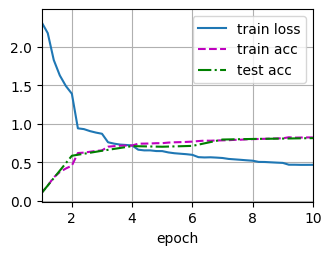

In [2]:
from torch import nn
from src.D2LFunction import *

# 原始 LeNet (AvgPool)
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.Sigmoid(),
    nn.Linear(84, 10))

batch_size = 256
train_iter, test_iter = load_data_fashion_mnist(batch_size=batch_size)
lr, num_epochs = 0.9, 10
train_ch6(net, train_iter, test_iter, num_epochs, lr, 'npu:0')

将 `AvgPool2d` 替换为 `MaxPool2d`：

loss 0.421, train acc 0.845, test acc 0.842
105267.2 examples/sec on npu:0


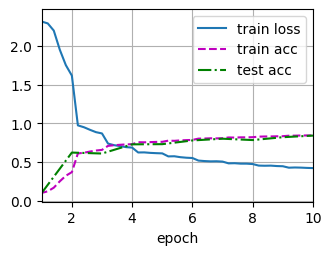

In [3]:
net_maxpool = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.Sigmoid(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.Sigmoid(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.Sigmoid(),
    nn.Linear(84, 10))

train_ch6(net_maxpool, train_iter, test_iter, num_epochs, lr, 'npu:0')

使用 `PyPTO` 编程进行验证:

loss 0.261, train acc 0.902, test acc 0.897
1640.6 examples/sec on npu:0


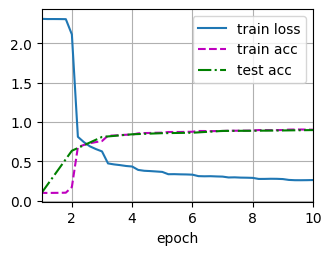

In [4]:
from src.PyPTOConv2DModule import PyPTOConv2d
from src.PyPTOPoolModule import PyPTOMaxPool2d
from src.PyPTOLinearFuseModule import PyPTOLinear

# 将 AvgPool2d 替换为 MaxPool2d
net_maxpool = nn.Sequential(
    PyPTOConv2d(1, 6, kernel_size=5, padding=2, bias=True, device=device), nn.Sigmoid(),
    PyPTOMaxPool2d(kernel_size=2, stride=2),
    PyPTOConv2d(6, 16, kernel_size=5, bias=True, device=device), nn.Sigmoid(),
    PyPTOMaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    PyPTOLinear(16 * 5 * 5, 120), nn.Sigmoid(),
    PyPTOLinear(120, 84), nn.Sigmoid(),
    PyPTOLinear(84, 10)).to(device)

batch_size = 32
train_iter, test_iter = load_data_fashion_mnist(batch_size=batch_size)
lr, num_epochs = 0.9, 10
train_ch6(net_maxpool, train_iter, test_iter, num_epochs, lr, 'npu:0')

---

## 练习 6.6.2

尝试构建一个基于`LeNet`的更复杂的网络，以提高其准确性。
1. 调整卷积窗口大小。
2. 调整输出通道的数量。
3. 调整激活函数（如`ReLU`）。
4. 调整卷积层的数量。
5. 调整全连接层的数量。
6. 调整学习率和其他训练细节（例如，初始化和轮数）。

### 解答

**第1问：**

&emsp;&emsp;修改为`nn.Conv2d(1, 6, kernel_size = 7)`

以下使用 `torch` 编程进行验证：

loss 0.446, train acc 0.836, test acc 0.837
101306.5 examples/sec on npu:0


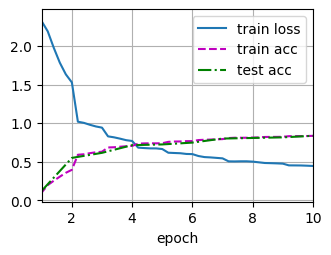

In [5]:
import torch
from torch import nn
from src.D2LFunction import *

# 调整卷积窗口大小: 5→7
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=7, padding=2),
    nn.Sigmoid(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=7),
    nn.Sigmoid(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16 * 3 * 3, 120),
    nn.Sigmoid(),
    nn.Linear(120, 84),
    nn.Sigmoid(),
    nn.Linear(84, 10))

batch_size = 256
train_iter, test_iter = load_data_fashion_mnist(batch_size=batch_size)
lr, num_epochs = 0.9, 10
train_ch6(net, train_iter, test_iter, num_epochs, lr, 'npu:0')

使用 `PyPTO` 编程进行验证:

以下用 `PyPTO` 模块构建与上方 `torch` 一致的网络（卷积窗口大小为 $7\times7$），验证前向输出形状。

loss 0.291, train acc 0.890, test acc 0.882
771.5 examples/sec on npu:0


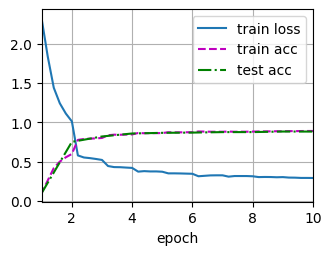

In [6]:
from torch import nn
from src.PyPTOConv2DModule import PyPTOConv2d
from src.PyPTOPoolModule import PyPTOMaxPool2d
from src.PyPTOLinearFuseModule import PyPTOLinear

# 调整卷积窗口大小: 5→7
net = nn.Sequential(
    PyPTOConv2d(1, 6, kernel_size=7, padding=2, bias=True, device=device),
    nn.Sigmoid(),
    PyPTOMaxPool2d(kernel_size=2, stride=2),
    PyPTOConv2d(6, 16, kernel_size=7, bias=True, device=device),
    nn.Sigmoid(),
    PyPTOMaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    PyPTOLinear(16 * 3 * 3, 120),
    nn.Sigmoid(),
    PyPTOLinear(120, 84),
    nn.Sigmoid(),
    PyPTOLinear(84, 10)).to(device)

batch_size = 32
train_iter, test_iter = load_data_fashion_mnist(batch_size=batch_size)
lr, num_epochs = 0.9, 10
train_ch6(net, train_iter, test_iter, num_epochs, lr, 'npu:0')

**第2问：**

&emsp;&emsp; 修改为`nn.Conv2d(1, 10, kernel_size = 5)`

以下使用 `torch` 编程进行验证：

loss 0.411, train acc 0.848, test acc 0.837
101477.5 examples/sec on npu:0


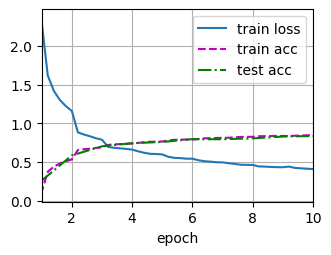

In [7]:
# 调整输出通道数量: conv1 out 6→10
net = nn.Sequential(
    nn.Conv2d(1, 10, kernel_size=5, padding=2),
    nn.Sigmoid(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(10, 16, kernel_size=5),
    nn.Sigmoid(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120),
    nn.Sigmoid(),
    nn.Linear(120, 84),
    nn.Sigmoid(),
    nn.Linear(84, 10))

batch_size = 256
train_iter, test_iter = load_data_fashion_mnist(batch_size=batch_size)
lr, num_epochs = 0.9, 10
train_ch6(net, train_iter, test_iter, num_epochs, lr, 'npu:0')

使用 `PyPTO` 编程进行验证:

以下用 `PyPTO` 模块构建与上方 `torch` 一致的网络（第一个卷积层输出通道数为 $10$），验证前向输出形状。

loss 0.256, train acc 0.905, test acc 0.887
1100.0 examples/sec on npu:0


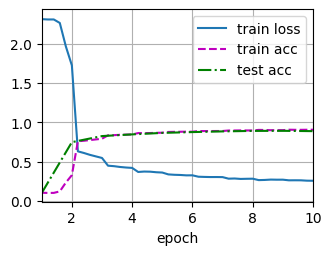

In [8]:
from torch import nn
from src.PyPTOConv2DModule import PyPTOConv2d
from src.PyPTOPoolModule import PyPTOMaxPool2d
from src.PyPTOLinearFuseModule import PyPTOLinear

# 调整输出通道数量: conv1 out 6→10
net = nn.Sequential(
    PyPTOConv2d(1, 10, kernel_size=5, padding=2, bias=True, device=device),
    nn.Sigmoid(),
    PyPTOMaxPool2d(kernel_size=2, stride=2),
    PyPTOConv2d(10, 16, kernel_size=5, bias=True, device=device),
    nn.Sigmoid(),
    PyPTOMaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    PyPTOLinear(16 * 5 * 5, 120),
    nn.Sigmoid(),
    PyPTOLinear(120, 84),
    nn.Sigmoid(),
    PyPTOLinear(84, 10)).to(device)

batch_size = 32
train_iter, test_iter = load_data_fashion_mnist(batch_size=batch_size)
lr, num_epochs = 0.9, 10
train_ch6(net, train_iter, test_iter, num_epochs, lr, 'npu:0')

**第3问：**

&emsp;&emsp; 将卷积层`nn.Sigmoid()`修改为`nn.ReLU()`

以下使用 `torch` 编程进行验证：

loss 0.261, train acc 0.902, test acc 0.875
101652.9 examples/sec on npu:0


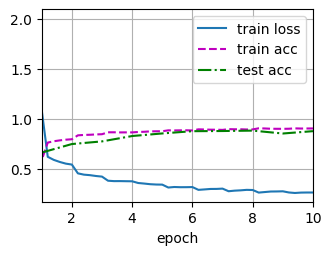

In [9]:
# 调整激活函数: Sigmoid→ReLU
net = nn.Sequential(
    nn.Conv2d(1, 10, kernel_size=5, padding=2),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(10, 16, kernel_size=5),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120),
    nn.Sigmoid(),
    nn.Linear(120, 84),
    nn.Sigmoid(),
    nn.Linear(84, 10))

batch_size = 256
train_iter, test_iter = load_data_fashion_mnist(batch_size=batch_size)
lr, num_epochs = 0.9, 10
train_ch6(net, train_iter, test_iter, num_epochs, lr, 'npu:0')

使用 `PyPTO` 编程进行验证:

以下用 `PyPTO` 模块构建与上方 `torch` 一致的网络（激活函数替换为 `ReLU`），验证前向输出形状。

loss 1.228, train acc 0.531, test acc 0.100
2372.3 examples/sec on npu:0


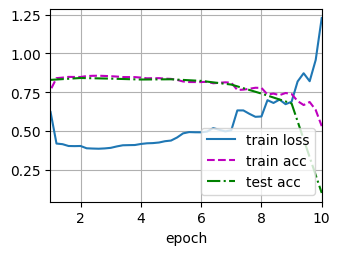

In [10]:
from torch import nn
from src.PyPTOConv2DModule import PyPTOConv2d
from src.PyPTOPoolModule import PyPTOMaxPool2d
from src.PyPTOLinearFuseModule import PyPTOLinear

# 调整激活函数: Sigmoid→ReLU
net = nn.Sequential(
    PyPTOConv2d(1, 10, kernel_size=5, padding=2, bias=True, device=device),
    nn.ReLU(),
    PyPTOMaxPool2d(kernel_size=2, stride=2),
    PyPTOConv2d(10, 16, kernel_size=5, bias=True, device=device),
    nn.ReLU(),
    PyPTOMaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    PyPTOLinear(16 * 5 * 5, 120),
    nn.Sigmoid(),
    PyPTOLinear(120, 84),
    nn.Sigmoid(),
    PyPTOLinear(84, 10)).to(device)

batch_size = 32
train_iter, test_iter = load_data_fashion_mnist(batch_size=batch_size)
lr, num_epochs = 0.9, 10
train_ch6(net, train_iter, test_iter, num_epochs, lr, 'npu:0')

**第4问：**

&emsp;&emsp; 添加`conv3`为`nn.Cov2d(16, 120, kernel_size = 5), ReLU()`

以下使用 `torch` 编程进行验证：

loss 0.248, train acc 0.906, test acc 0.865
95787.0 examples/sec on npu:0


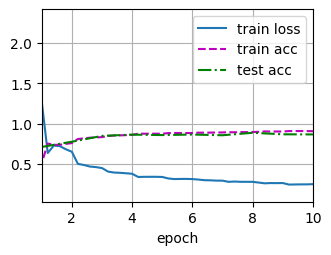

In [11]:
# 添加第三个卷积层 conv3
net = nn.Sequential(
    nn.Conv2d(1, 10, kernel_size=5, padding=2),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(10, 16, kernel_size=5),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(16, 120, kernel_size=5),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(120, 120),
    nn.Sigmoid(),
    nn.Linear(120, 84),
    nn.Sigmoid(),
    nn.Linear(84, 10))

batch_size = 256
train_iter, test_iter = load_data_fashion_mnist(batch_size=batch_size)
lr, num_epochs = 0.9, 10
train_ch6(net, train_iter, test_iter, num_epochs, lr, 'npu:0')

使用 `PyPTO` 编程进行验证:

以下用 `PyPTO` 模块构建与上方 `torch` 一致的网络（新增第三个卷积层），验证前向输出形状。

loss 2.410, train acc 0.098, test acc 0.100
618.8 examples/sec on npu:0


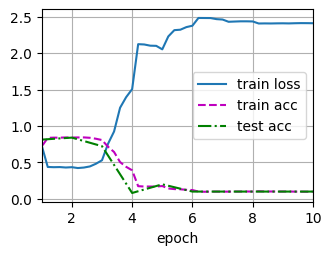

In [12]:
from torch import nn
from src.PyPTOConv2DModule import PyPTOConv2d
from src.PyPTOPoolModule import PyPTOMaxPool2d
from src.PyPTOLinearFuseModule import PyPTOLinear

# 添加第三个卷积层 conv3
net = nn.Sequential(
    PyPTOConv2d(1, 10, kernel_size=5, padding=2, bias=True, device=device),
    nn.ReLU(),
    PyPTOMaxPool2d(kernel_size=2, stride=2),
    PyPTOConv2d(10, 16, kernel_size=5, bias=True, device=device),
    nn.ReLU(),
    PyPTOMaxPool2d(kernel_size=2, stride=2),
    PyPTOConv2d(16, 120, kernel_size=5, bias=True, device=device),
    nn.ReLU(),
    nn.Flatten(),
    PyPTOLinear(120, 120),
    nn.Sigmoid(),
    PyPTOLinear(120, 84),
    nn.Sigmoid(),
    PyPTOLinear(84, 10)).to(device)

batch_size = 32
train_iter, test_iter = load_data_fashion_mnist(batch_size=batch_size)
lr, num_epochs = 0.9, 10
train_ch6(net, train_iter, test_iter, num_epochs, lr, 'npu:0')

**第5问：**

&emsp;&emsp; 添加`nn.Linear(84, 20),nn.Sigmoid()`并将`nn.Linear(84, 10)`替换

以下使用 `torch` 编程进行验证：

loss 0.302, train acc 0.890, test acc 0.882
87333.8 examples/sec on npu:0


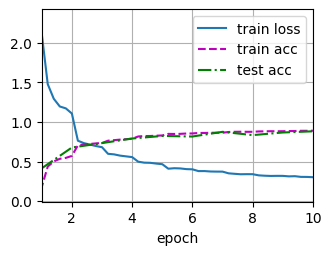

In [13]:
# 添加全连接层 Linear(84,20)
net = nn.Sequential(
    nn.Conv2d(1, 10, kernel_size=5, padding=2),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(10, 16, kernel_size=5),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(16, 120, kernel_size=5),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(120, 120),
    nn.Sigmoid(),
    nn.Linear(120, 84),
    nn.Sigmoid(),
    nn.Linear(84, 20),
    nn.Sigmoid(),
    nn.Linear(20, 10))

batch_size = 256
train_iter, test_iter = load_data_fashion_mnist(batch_size=batch_size)
lr, num_epochs = 0.9, 10
train_ch6(net, train_iter, test_iter, num_epochs, lr, 'npu:0')

使用 `PyPTO` 编程进行验证:

以下用 `PyPTO` 模块构建与上方 `torch` 一致的网络（新增全连接层 `Linear(84,20)`），验证前向输出形状。

loss 2.344, train acc 0.099, test acc 0.100
1105.2 examples/sec on npu:0


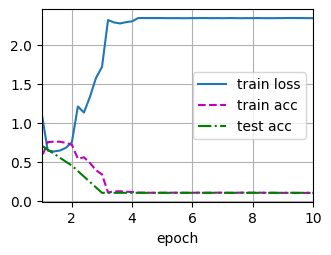

In [14]:
from torch import nn
from src.PyPTOConv2DModule import PyPTOConv2d
from src.PyPTOPoolModule import PyPTOMaxPool2d
from src.PyPTOLinearFuseModule import PyPTOLinear

# 添加全连接层 Linear(84,20)
net = nn.Sequential(
    PyPTOConv2d(1, 10, kernel_size=5, padding=2, bias=True, device=device),
    nn.ReLU(),
    PyPTOMaxPool2d(kernel_size=2, stride=2),
    PyPTOConv2d(10, 16, kernel_size=5, bias=True, device=device),
    nn.ReLU(),
    PyPTOMaxPool2d(kernel_size=2, stride=2),
    PyPTOConv2d(16, 120, kernel_size=5, bias=True, device=device),
    nn.ReLU(),
    nn.Flatten(),
    PyPTOLinear(120, 120),
    nn.Sigmoid(),
    PyPTOLinear(120, 84),
    nn.Sigmoid(),
    PyPTOLinear(84, 20),
    nn.Sigmoid(),
    PyPTOLinear(20, 10)).to(device)

batch_size = 32
train_iter, test_iter = load_data_fashion_mnist(batch_size=batch_size)
lr, num_epochs = 0.9, 10
train_ch6(net, train_iter, test_iter, num_epochs, lr, 'npu:0')

**第6问：**

&emsp;&emsp; 修改为`lr, num_epochs = 0.1, 50`

以下使用 `torch` 编程进行验证：

loss 0.101, train acc 0.962, test acc 0.865
11365.9 examples/sec on npu:0


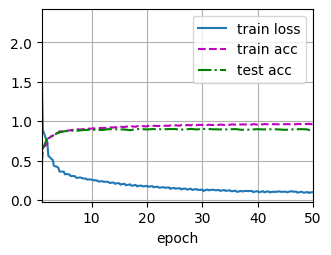

In [15]:
# 调整学习率和训练轮数: lr 0.9→0.1, epochs 10→50
net = nn.Sequential(
    nn.Conv2d(1, 10, kernel_size=5, padding=2),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(10, 16, kernel_size=5),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(16, 120, kernel_size=5),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(120, 120),
    nn.Sigmoid(),
    nn.Linear(120, 84),
    nn.Sigmoid(),
    nn.Linear(84, 20),
    nn.Sigmoid(),
    nn.Linear(20, 10))

lr, num_epochs = 0.1, 50
train_ch6(net, train_iter, test_iter, num_epochs, lr, 'npu:0')

使用 `PyPTO` 编程进行验证:

以下用 `PyPTO` 模块构建与上方 `torch` 一致的网络（学习率调整为 $0.1$）进行训练。由于 `PyPTO` 纯向量卷积实现的单次迭代内核负载较大，长时间训练易触发 AICore 看门狗超时（aicore exception 507015），这里将训练轮数降为 $10$ 以验证正确性；$50$ 轮的训练效果由上方 `torch` 版本展示。

In [ ]:
from src.D2LFunction import *

loss 0.263, train acc 0.903, test acc 0.881
470.8 examples/sec on npu:0


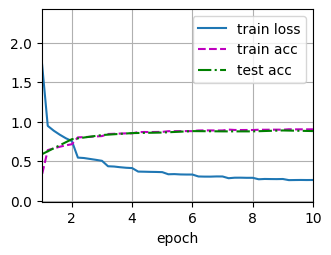

In [3]:
from torch import nn
from src.PyPTOConv2DModule import PyPTOConv2d
from src.PyPTOPoolModule import PyPTOMaxPool2d
from src.PyPTOLinearFuseModule import PyPTOLinear

# 调整学习率和训练轮数: lr 0.9→0.1；PyPTO 纯向量实现内核负载大，epochs 降为 10 避免超时
net = nn.Sequential(
    PyPTOConv2d(1, 10, kernel_size=5, padding=2, bias=True, device=device),
    nn.ReLU(),
    PyPTOMaxPool2d(kernel_size=2, stride=2),
    PyPTOConv2d(10, 16, kernel_size=5, bias=True, device=device),
    nn.ReLU(),
    PyPTOMaxPool2d(kernel_size=2, stride=2),
    PyPTOConv2d(16, 120, kernel_size=5, bias=True, device=device),
    nn.ReLU(),
    nn.Flatten(),
    PyPTOLinear(120, 120),
    nn.Sigmoid(),
    PyPTOLinear(120, 84),
    nn.Sigmoid(),
    PyPTOLinear(84, 20),
    nn.Sigmoid(),
    PyPTOLinear(20, 10)).to(device)

batch_size = 32
train_iter, test_iter = load_data_fashion_mnist(batch_size=batch_size)
lr, num_epochs = 0.1, 10
train_ch6(net, train_iter, test_iter, num_epochs, lr, 'npu:0')


---

## 练习 6.6.3

在`MNIST`数据集上尝试以上改进的网络。

### 解答

以下使用 `torch` 编程进行验证：

In [5]:
from torch import nn

loss 0.111, train acc 0.958, test acc 0.904
11871.1 examples/sec on npu:0


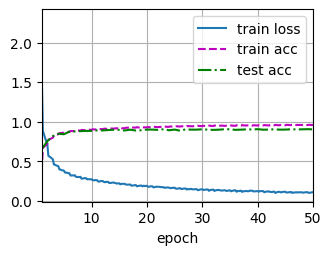

In [6]:
# 使用 6.6.2 改进后的网络结构在 MNIST 上训练
net = nn.Sequential(
    nn.Conv2d(1, 10, kernel_size=5, padding=2),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(10, 16, kernel_size=5),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(16, 120, kernel_size=5),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(120, 120),
    nn.Sigmoid(),
    nn.Linear(120, 84),
    nn.Sigmoid(),
    nn.Linear(84, 20),
    nn.Sigmoid(),
    nn.Linear(20, 10))

lr, num_epochs = 0.1, 50
train_ch6(net, train_iter, test_iter, num_epochs, lr, 'npu:0')

使用 `PyPTO` 编程进行验证:

loss 0.263, train acc 0.904, test acc 0.892
1129.9 examples/sec on npu:0


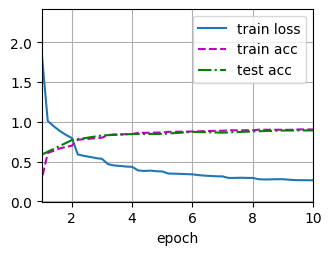

In [4]:
from torch import nn
from src.PyPTOConv2DModule import PyPTOConv2d
from src.PyPTOPoolModule import PyPTOMaxPool2d
from src.PyPTOLinearFuseModule import PyPTOLinear

# 使用 6.6.2 改进后的网络结构 (与 torch 版本一致)；PyPTO 内核负载大，epochs 降为 10 避免超时
net = nn.Sequential(
    PyPTOConv2d(1, 10, kernel_size=5, padding=2, bias=True, device=device),
    nn.ReLU(),
    PyPTOMaxPool2d(kernel_size=2, stride=2),
    PyPTOConv2d(10, 16, kernel_size=5, bias=True, device=device),
    nn.ReLU(),
    PyPTOMaxPool2d(kernel_size=2, stride=2),
    PyPTOConv2d(16, 120, kernel_size=5, bias=True, device=device),
    nn.ReLU(),
    nn.Flatten(),
    PyPTOLinear(120, 120),
    nn.Sigmoid(),
    PyPTOLinear(120, 84),
    nn.Sigmoid(),
    PyPTOLinear(84, 20),
    nn.Sigmoid(),
    PyPTOLinear(20, 10)).to(device)

batch_size = 32
train_iter, test_iter = load_data_fashion_mnist(batch_size=batch_size)
lr, num_epochs = 0.1, 10
train_ch6(net, train_iter, test_iter, num_epochs, lr, 'npu:0')

---

## 练习 6.6.4

显示不同输入（例如毛衣和外套）时，`LeNet`第一层和第二层的激活值。

### 解答

以下使用 `torch` 编程进行验证：

Conv2d output shape: torch.Size([256, 6, 28, 28])
Sigmoid output shape: torch.Size([256, 6, 28, 28])
AvgPool2d output shape: torch.Size([256, 6, 14, 14])
Conv2d output shape: torch.Size([256, 16, 10, 10])
Sigmoid output shape: torch.Size([256, 16, 10, 10])


array([<Axes: title={'center': 'coat'}>,
       <Axes: title={'center': 'pullover'}>,
       <Axes: title={'center': 'trouser'}>,
       <Axes: title={'center': 'shirt'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 'dress'}>], dtype=object)

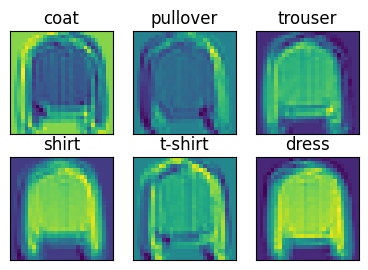

In [9]:
# 展示 LeNet 第一层和第二层的激活值
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2),
    nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5),
    nn.Sigmoid())

net = net.to('npu:0')
batch_size = 256
train_iter, test_iter = load_data_fashion_mnist(batch_size=batch_size)
X, y = next(iter(train_iter))
X = X.to('npu:0')

activations = []
for layer in net:
    X = layer(X)
    activations.append(X)
    print(f'{layer.__class__.__name__} output shape: {X.shape}')

show_images(activations[0][0, :6].squeeze().detach().cpu(), 2, 3, titles=get_fashion_mnist_labels(y[:6]))

使用 `PyPTO` 编程进行验证:

以下使用 `PyPTO` 模块构建与上方 `torch` 一致的 LeNet 前半部分（卷积 + 汇聚），计算第一层和第二层的激活值。

PyPTOConv2d output shape: torch.Size([32, 6, 28, 28])
Sigmoid output shape: torch.Size([32, 6, 28, 28])
PyPTOAvgPool2d output shape: torch.Size([32, 6, 14, 14])
PyPTOConv2d output shape: torch.Size([32, 16, 10, 10])
Sigmoid output shape: torch.Size([32, 16, 10, 10])


array([<Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 'coat'}>,
       <Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 'trouser'}>,
       <Axes: title={'center': 'shirt'}>], dtype=object)

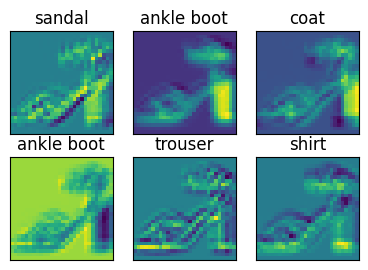

In [10]:
from torch import nn
from src.PyPTOConv2DModule import PyPTOConv2d
from src.PyPTOPoolModule import PyPTOAvgPool2d

# 展示 LeNet 第一层和第二层的激活值 (与 torch 网络结构一致)
net = nn.Sequential(
    PyPTOConv2d(1, 6, kernel_size=5, padding=2),
    nn.Sigmoid(),
    PyPTOAvgPool2d(kernel_size=2, stride=2),
    PyPTOConv2d(6, 16, kernel_size=5),
    nn.Sigmoid())

batch_size = 32
train_iter, test_iter = load_data_fashion_mnist(batch_size=batch_size)
X, y = next(iter(train_iter))
X = X.to('npu:0')

activations = []
for layer in net:
    X = layer(X)
    activations.append(X)
    print(f'{layer.__class__.__name__} output shape: {X.shape}')

show_images(activations[0][0, :6].squeeze().detach().cpu(), 2, 3, titles=get_fashion_mnist_labels(y[:6]))


---
## 参考答案来源
参考答案和 PyTorch 代码实现来源：[https://datawhalechina.github.io/d2l-ai-solutions-manual/#](https://datawhalechina.github.io/d2l-ai-solutions-manual/#)